# Tide adjustment in the Ria de Ferrol: one boundary, two methods, one judge

**The question.** Every satellite-derived intertidal DEM assigns a water level
to each scene. That level comes from a *boundary* — an ocean tide model, a
harbour tide gauge, or both — and it is only right at the mouth. Inside the
estuary the tide arrives late, so two published families of methods measure
that lag from the imagery itself and read the boundary on a shifted clock:

| method | what it measures | how | estimator of elevation |
|---|---|---|---|
| **MAREA** (ours) | one clock lag per band of distance from the mouth | profiled Bernoulli likelihood of the binary wet/dry record; only phase is identifiable (affine theorem) so gain and datum stay with the boundary | closed-form NDWI sigmoid, `marea.invert_series` |
| **Granadeiro et al. 2021** | one lag per pixel, smoothed by thin-plate spline | rising vs ebbing logistic fits on standardised NIR, lag that reconciles them, TPS over a sample | 4-parameter logistic on NIR, elevation = inflection |

**The boundary interface.** Two switches, nothing else: `TIDE_MODEL` (a pyTMD
model name, or `None`) and `N_GAUGES` (the N nearest IOC gauges, inverse-
distance blended, or `None`). Both set → the consensus of the two. The same
provider feeds MAREA, Granadeiro and the plain inversion, so what changes
between rows is the *method*, never the data.

**The site.** The Ria de Ferrol has the only Spanish IOC gauge pair on one axis: Ferrol1 at the outer ria and Ferrol2 6.4 km in. Ferrol2 is
**held out** as the judge — never a member of the boundary, never seen by
either fit. A method that claims to measure the interior clock must predict
the level Ferrol2 measured.

**What we produce**

| product | what it answers |
|---|---|
| bathymetry without vs with MAREA | what the measured clock does to the map (same inversion, only the clock changes) |
| MAREA vs Granadeiro | two clocks, two estimators — and a crossed row that isolates the clock from the estimator |
| level error at the judge gauge | the number that decides: RMSE of the predicted water level at Ferrol2, per method |

**Two decisions, stated up front.**

1. *Without vs with MAREA* uses the **same inversion** (`marea.invert_series`)
   on the same pixels and scenes; only the level series differs. Anything else
   would confound the clock with the estimator.
2. *MAREA vs Granadeiro* keeps **each method's own estimator**, because the
   published method is the whole recipe, not just its lag. A **crossed row**
   — Granadeiro's lag map fed into our inversion — then separates what the
   clock contributes from what the estimator contributes.

## Parameters

Everything that changes between one run and another lives in the next cell.
`TIDE_MODEL` and `N_GAUGES` are the two boundary switches; `JUDGE_GAUGES`
names the instruments held out from the boundary, whatever their distance.

In [1]:
# ── Which area, and over what period ────────────────────────────────────
SITE         = "ferrol"                       # registry key
TIME_EXTENT  = ("2023-01-01", "2025-12-31")
RESOLUTION_M = 10                              # the cached cube's grid
CACHE        = "ndwi_cube_ferrol_2023-2025_10m.nc"
OUT_DIR      = "products_ferrol"

# ── The boundary: two switches ──────────────────────────────────────────
TIDE_MODEL   = "EOT20"        # pyTMD model name, or None
N_GAUGES     = 1              # N nearest IOC gauges (IDW blend), or None
JUDGE_GAUGES = ['fer2']       # held out: never in the boundary (Ferrol2)
MOUTH_SIDE   = "west"   # the sea is on the west edge of the box:
                              # distance from the mouth is measured from
                              # the sea on those edge(s) only

# ── Derived ─────────────────────────────────────────────────────────────
BOUNDARY_TAG = f"{(TIDE_MODEL or 'nomodel').lower()}_g{N_GAUGES or 0}"
print(f"run {SITE!r} · {TIME_EXTENT[0]} → {TIME_EXTENT[1]} @ {RESOLUTION_M} m")
print(f"  boundary  model={TIDE_MODEL}  gauges={N_GAUGES}  "
      f"held out={JUDGE_GAUGES}  → tag {BOUNDARY_TAG}")
print(f"  cache     {CACHE}")
print(f"  outputs   {OUT_DIR}")

run 'ferrol' · 2023-01-01 → 2025-12-31 @ 10 m
  boundary  model=EOT20  gauges=1  held out=['fer2']  → tag eot20_g1
  cache     ndwi_cube_ferrol_2023-2025_10m.nc
  outputs   products_ferrol


## 0 · Setup

No Copernicus connection is needed: the cube is cached. The certificate fix is
still required, because the overpass times come from the catalogue.

In [2]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyintertidal as pit
from pyintertidal import SentinelCube, explain, viz, marea
from pyintertidal import tide_estimators as te
from pyintertidal.boundary import make_boundary, nearest_gauges
from pyintertidal.gauges import load_cached_ioc, despike

pit.net.use_system_certificates()
os.makedirs(OUT_DIR, exist_ok=True)
print("pyintertidal", pit.__version__)
log = explain.OpLog(f"Escalda {TIME_EXTENT[0][:4]}–{TIME_EXTENT[1][:4]}")

pyintertidal 0.1.0


## 1 · Study area and its instruments

The polygon comes from the registry. The gauges come from the IOC station
list: the N nearest that are not held out form the boundary, the held-out
ones judge.

AOI('Ferrol', 151.1 km², [-8.360, 43.440, -8.150, 43.520])
  centroid 43.480, -8.255

IOC gauges around the site:
  fer2  Ferrol2                        0.7 km   JUDGE (held out)
  fer1  Ferrol1                        6.0 km   BOUNDARY member
  coru  La Coruña                     17.2 km   unused
  acor1 A Coruña                      17.3 km   unused
  cor2  Acoruna                       17.4 km   unused
  lang  Langosteira                   26.7 km   unused


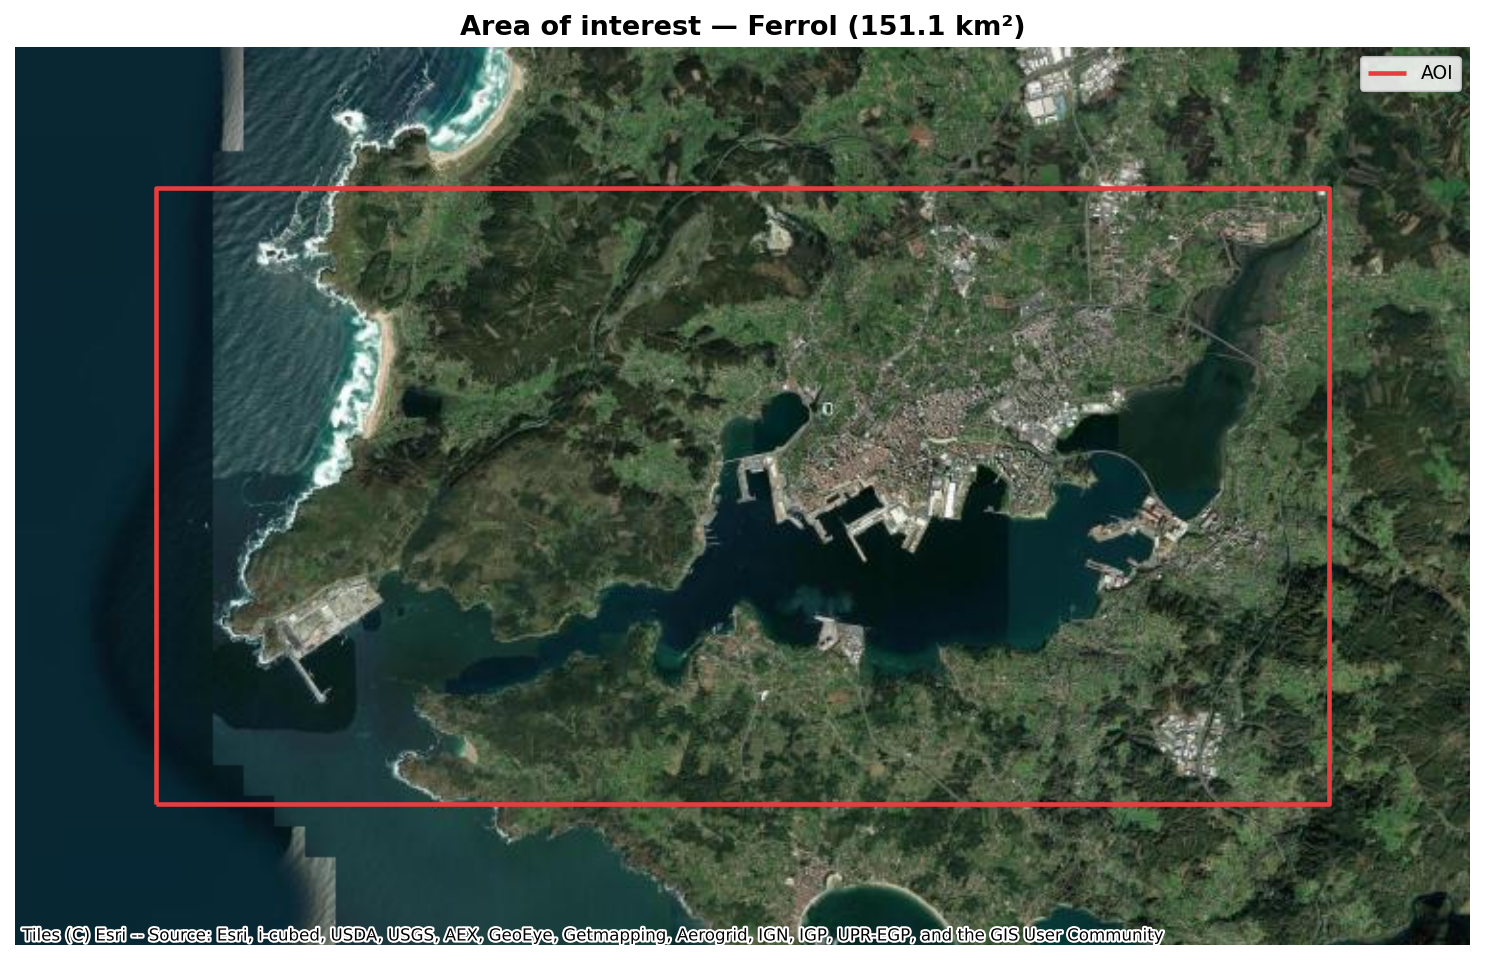

In [3]:
aoi = pit.sites.get(SITE)
print(aoi)
lat_c, lon_c = aoi.centroid
print(f"  centroid {lat_c:.3f}, {lon_c:.3f}")

stations = {s["Code"]: s for s in json.load(
    open("data_v4/gauges/ioc_stations.json", encoding="utf-8"))}
near = nearest_gauges(lat_c, lon_c, 6)
members = [g for g in near if g[0] not in JUDGE_GAUGES][:(N_GAUGES or 0)]
member_codes = [g[0] for g in members]
print("\nIOC gauges around the site:")
for code_, name, km in near:
    role = ("BOUNDARY member" if code_ in member_codes else
            "JUDGE (held out)" if code_ in JUDGE_GAUGES else "unused")
    print(f"  {code_:5s} {name:28s} {km:5.1f} km   {role}")
viz.plot_aoi(aoi);

## 2 · The datacube

Cached at 20 m for 2023–2025 (B03, B08, SCL). Every later step streams it.

In [4]:
WATER = "ndwi"
cube = SentinelCube(aoi, TIME_EXTENT, water=WATER, cache_path=CACHE,
                    resolution=RESOLUTION_M)
cube.ensure(None)                       # cached → no connection needed
transform, crs = cube.grid
H, W = cube.shape
px_km2 = abs(transform.a * transform.e) / 1e6
print(f"{len(cube.dates)} scenes · grid {H}×{W} @ {abs(transform.a):g} m · {crs}")
explain.dates_available(cube.dates, TIME_EXTENT)

[cube] using cache ndwi_cube_ferrol_2023-2025_10m.nc


461 scenes · grid 905×1707 @ 10 m · EPSG:32629


<pyintertidal summary — display it in a notebook>

## 3 · Water detection threshold

Otsu over the clearest scenes suggests the cut; the adopted value is written
out. MAREA's extraction uses the same convention (wet when NDWI > 0).

In [5]:
otsu, info = pit.water.calibrate_threshold(cube, n_scenes=12)
NDWI_THRESHOLD = 0.0
print(f"\nadopted NDWI threshold: {NDWI_THRESHOLD:+.3f}")

[water] Otsu on 405,006 clear pixels from 12 scenes → -0.137

adopted NDWI threshold: +0.000


## 4 · Coastal stability, cloud screening, water frequency, intertidal zone

The same four steps as the Villaviciosa study, with the same parameters.

  class 0 (transition   ):  525,024 px   52.50 km²
  class 1 (stable water ):  157,467 px   15.75 km²
  class 2 (stable land  ):  862,344 px   86.23 km²
106 usable dates


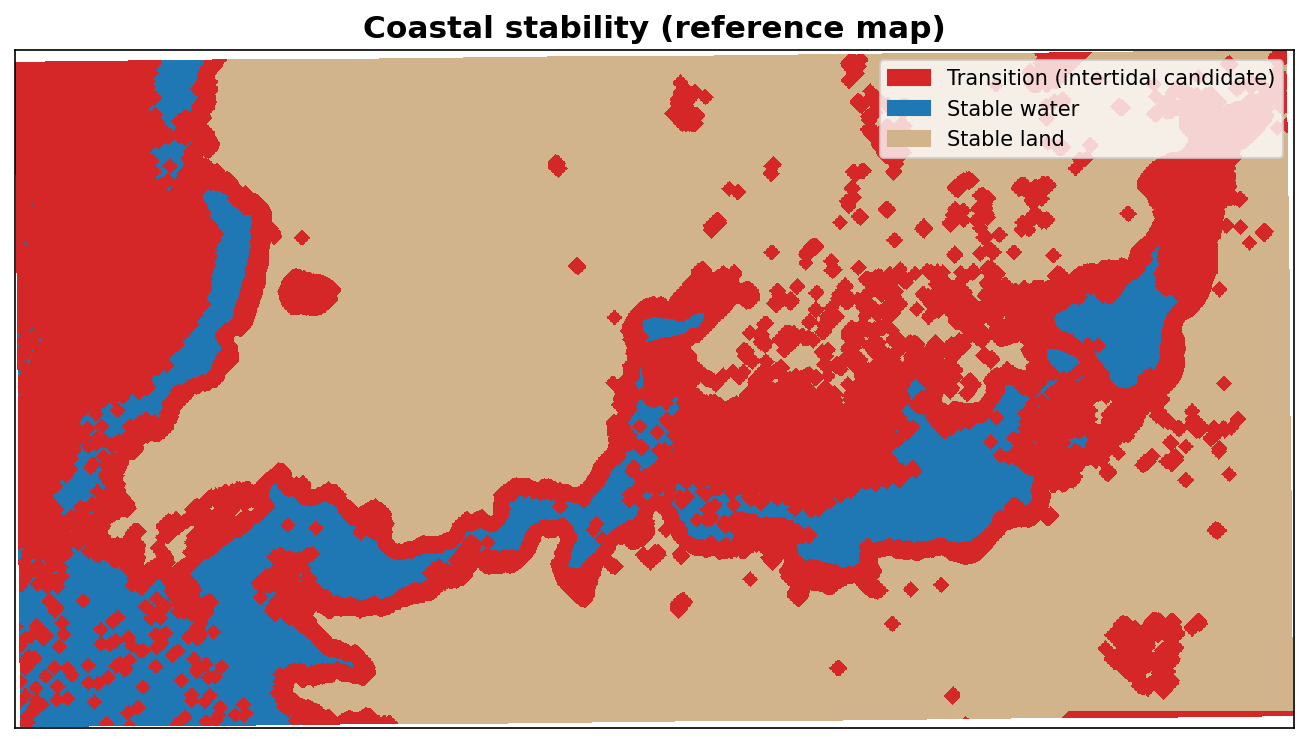

In [6]:
CLEAN_SCENE_MAX_BAD  = 0.05
STABLE_THRESHOLD     = 0.95
TRANSITION_BUFFER_PX = 10
CLOUD_THRESHOLD      = 0.10

reference_map, cloud_pct = pit.reference_and_clouds(
    cube, threshold=NDWI_THRESHOLD, bad_classes=pit.water.BAD_CLASSES,
    clean_scene_max_bad=CLEAN_SCENE_MAX_BAD, stable_threshold=STABLE_THRESHOLD,
    transition_buffer_px=TRANSITION_BUFFER_PX)
for code_, name in [(0, "transition"), (1, "stable water"), (2, "stable land")]:
    n = int((reference_map == code_).sum())
    print(f"  class {code_} ({name:13s}): {n:>8,} px  {n * px_km2:6.2f} km²")
usable_dates = pit.filter_dates(cloud_pct, cloud_threshold=CLOUD_THRESHOLD)
print(f"{len(usable_dates)} usable dates")
log.record("reference map + cloud stats", kind="reduce",
           params={"stable_threshold": STABLE_THRESHOLD}, inputs=["cube"],
           outputs=["reference map", f"{len(usable_dates)} dates"])
viz.plot_reference_map(reference_map, transform, crs, aoi);

multi-Otsu window [0.25, 0.73]; adopted [0.05, 0.95] → intertidal 114,706 px = 11.47 km²


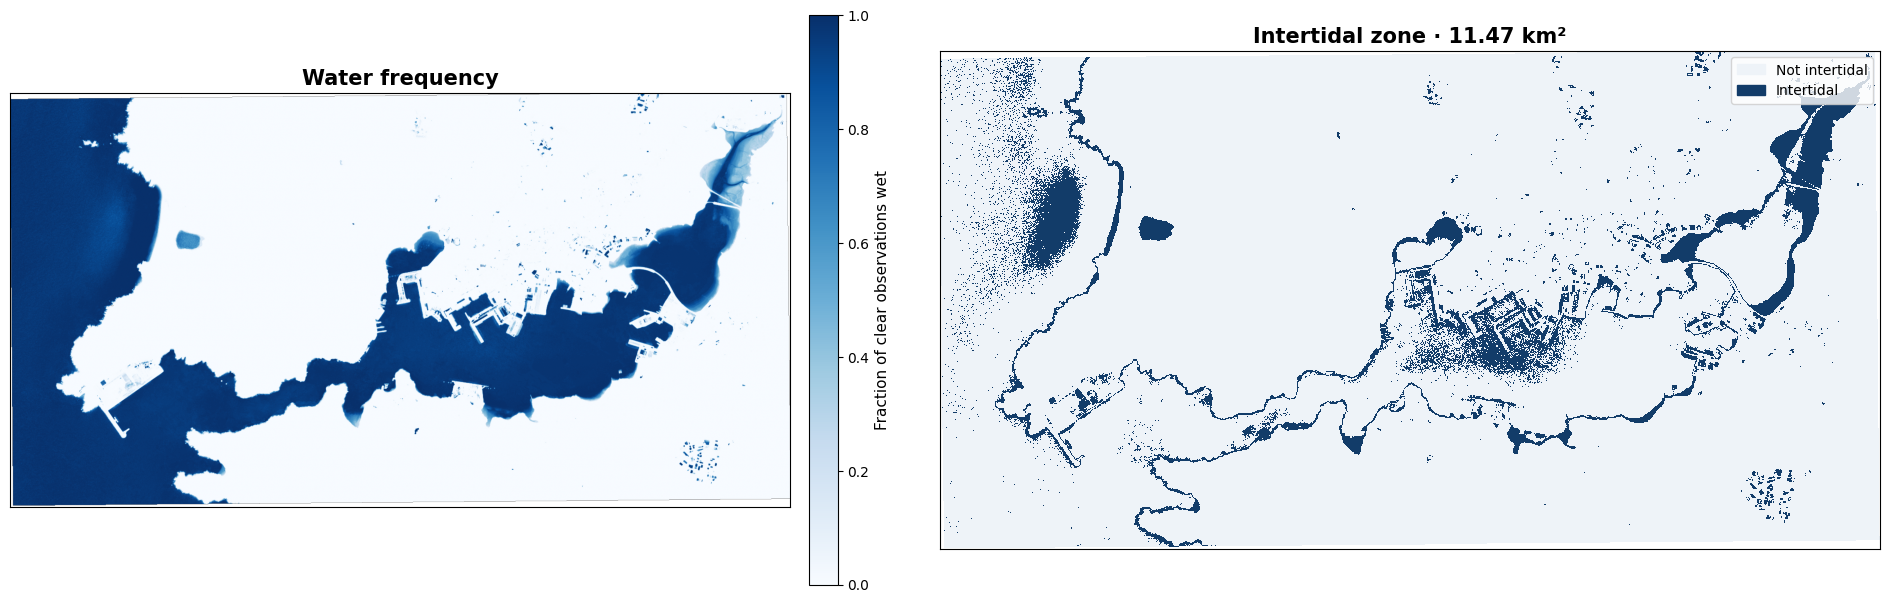

In [7]:
MIN_OBS = max(8, round(0.05 * len(usable_dates)))
water_freq = pit.water_frequency(cube, dates=usable_dates,
                                 threshold=NDWI_THRESHOLD, min_obs=MIN_OBS)
transition = reference_map == 0
otsu_low, otsu_high = pit.multiotsu_window(water_freq, transition)
WF_LOW, WF_HIGH = 0.05, 0.95
polygon_mask = aoi.raster_mask(transform, crs, reference_map.shape)
intertidal = pit.intertidal_mask(water_freq, reference_map, WF_LOW, WF_HIGH,
                                 aoi_mask=polygon_mask)
area_km2 = intertidal.sum() * px_km2
print(f"multi-Otsu window [{otsu_low:.2f}, {otsu_high:.2f}]; adopted "
      f"[{WF_LOW}, {WF_HIGH}] → intertidal {int(intertidal.sum()):,} px = "
      f"{area_km2:.2f} km²")
log.record("intertidal mask", kind="mask", params={"wf": [WF_LOW, WF_HIGH]},
           outputs=["intertidal mask"], note=f"{area_km2:.2f} km²")
fig, axes = plt.subplots(1, 2, figsize=(19, 7))
viz.plot_water_frequency(water_freq, transform, crs, aoi, ax=axes[0])
viz.plot_intertidal(intertidal, transform, crs, aoi,
                    title=f"Intertidal zone · {area_km2:.2f} km²", ax=axes[1])
fig.tight_layout();

## 5 · The boundary

One call builds the provider from the two switches. Whatever it is — model,
gauges or consensus — the rest of the notebook only ever calls
`boundary.levels(times)`.

The three options are drawn together over a spring tide so the differences
are visible: the gauges carry surge and the harbour's own harmonics, the
model carries neither; the consensus halves both.

Two honesties about gauge records. IOC files carry sentinel spikes (a few
samples at −10 m) and holes (Vlissingen is dark from 2023-09 to 2025-03):
`make_boundary` drops the spikes with a rolling-median rule and never bridges
a hole — a missing gauge simply leaves the blend, and when every gauge is
missing the consensus falls back to the model alone (about 6 % of this
period). The judge record below is cleaned with the same rule.

[boundary] gauge fer1 (Ferrol1) at 6 km: 1,464,630 samples (2971 spikes dropped)
boundary: consensus EOT20 + fer1


Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

  model EOT20            range [-2.20, +2.22] m, finite 100.0%

  1 nearest gauges       range [-2.27, +2.60] m, finite 95.1%

  consensus              range [-2.21, +2.30] m, finite 100.0%

  boundary               range [-2.21, +2.30] m, finite 100.0%

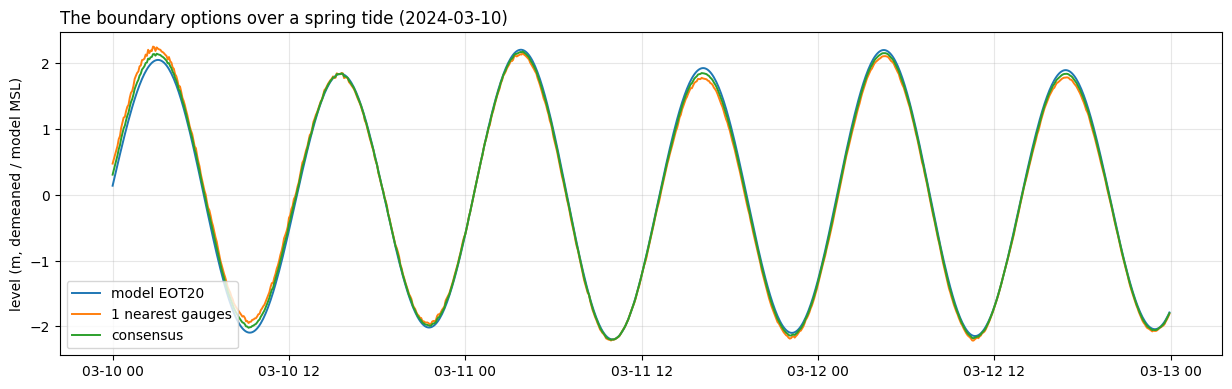

In [8]:
boundary = make_boundary(aoi, tide_model=TIDE_MODEL, n_gauges=N_GAUGES,
                         period=TIME_EXTENT, exclude=JUDGE_GAUGES)
print(f"boundary: {boundary.name}")

# the alternatives, for the record (cached gauges → cheap)
options = {}
if TIDE_MODEL:
    options[f"model {TIDE_MODEL}"] = make_boundary(
        aoi, TIDE_MODEL, None, period=TIME_EXTENT, exclude=JUDGE_GAUGES,
        verbose=False)
if N_GAUGES:
    options[f"{N_GAUGES} nearest gauges"] = make_boundary(
        aoi, None, N_GAUGES, period=TIME_EXTENT, exclude=JUDGE_GAUGES,
        verbose=False)
if TIDE_MODEL and N_GAUGES:
    options["consensus"] = boundary

# a 5-minute grid of every option over the whole period: the record every
# metric below reads, shifted in time by interpolation when a clock applies
grid5 = pd.date_range(TIME_EXTENT[0], pd.Timestamp(TIME_EXTENT[1]) + pd.Timedelta(days=1),
                      freq="5min")
lev5 = {k: np.asarray(v.levels(grid5), float) for k, v in options.items()}
lev5["boundary"] = np.asarray(boundary.levels(grid5), float)
for k, v in lev5.items():
    print(f"  {k:22s} range [{np.nanmin(v):+.2f}, {np.nanmax(v):+.2f}] m, "
          f"finite {np.isfinite(v).mean():.1%}")

# three days around a spring tide
rng_day = pd.Series(lev5["boundary"], index=grid5).resample("1D").agg(
    lambda x: np.nanmax(x) - np.nanmin(x))
d0 = rng_day.idxmax() - pd.Timedelta(days=1)
win = (grid5 >= d0) & (grid5 < d0 + pd.Timedelta(days=3))
fig, ax = plt.subplots(figsize=(15, 4.2))
for k, v in lev5.items():
    if k == "boundary":
        continue
    ax.plot(grid5[win], v[win], lw=1.4, label=k)
ax.set_ylabel("level (m, demeaned / model MSL)")
ax.set_title(f"The boundary options over a spring tide ({d0.date()})",
             loc="left"); ax.grid(alpha=0.3); ax.legend();

## 6 · Tide at each scene, and is the site mappable?

Every usable date is paired with its real acquisition time and the boundary
is read there. The sampling diagnostics put a ceiling on what any method can
reconstruct here.

overpass times from the catalogue: 462 dates (cached)

Modelling tides with EOT20

106 of 106 usable dates have an overpass time and a finite boundary level


Tidal sampling · Ferrol


TIDAL RANGE COVERAGE

...


REPRESENTATIVITY

  9/10 quantiles sampled (90%)


VERDICT: LIMITED

  - only 64% of the tidal range was imaged (0.37 m missing at the bottom, 1.22 m at the top)

Operation(name='boundary levels', kind='apply', params={'tide_model': 'EOT20', 'n_gauges': 1, 'held_out': ['fer2']}, inputs=[], outputs=['106 scene levels'], before=None, after=None, note='', seconds=0.0)

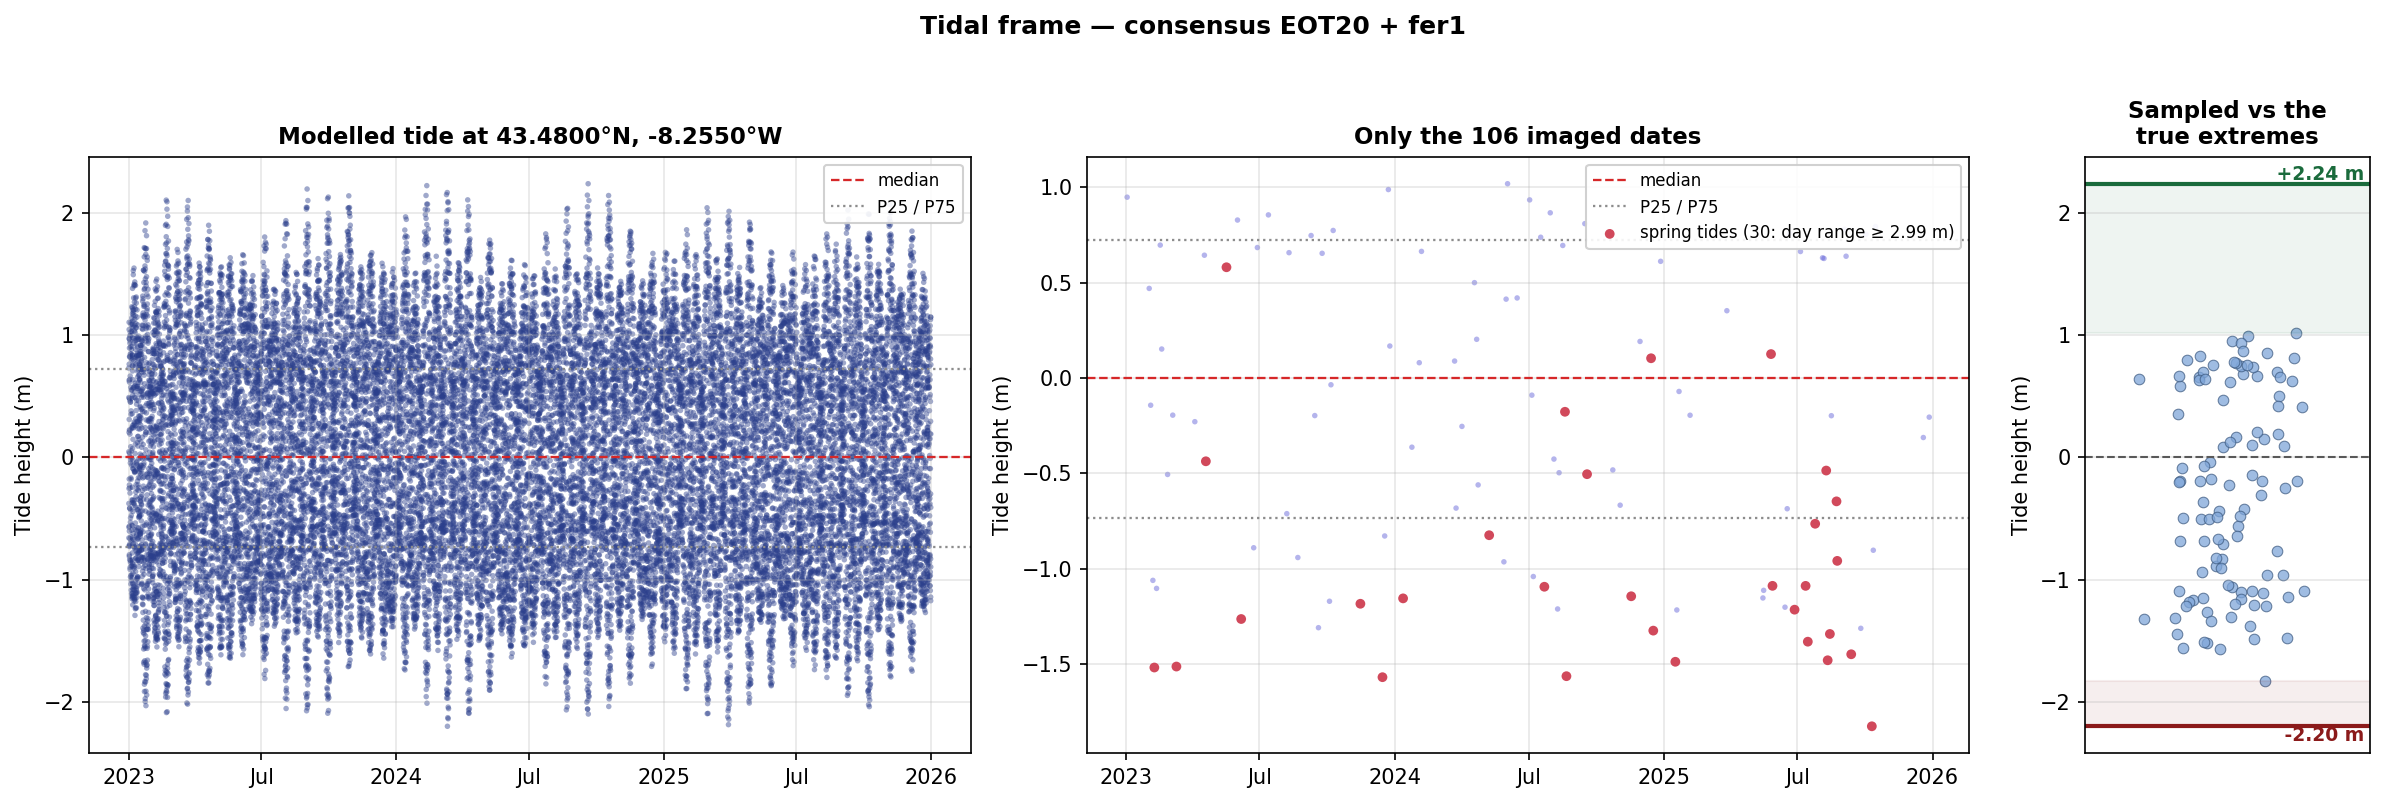

In [9]:
# the catalogue lookup, cached on disk: a Sentinel-2 STAC outage must not
# cost a 40-minute run (it did, twice)
OVERPASS_CACHE = f"{OUT_DIR}/overpass_times.json"
if os.path.exists(OVERPASS_CACHE):
    overpass = {k: pd.Timestamp(v).to_pydatetime() for k, v in
                json.load(open(OVERPASS_CACHE)).items()}
    print(f"overpass times from cache: {len(overpass)} dates")
else:
    overpass = pit.overpass.get_overpass_times(aoi.bbox, TIME_EXTENT, verbose=False)
    json.dump({k: v.isoformat() for k, v in overpass.items()}, open(OVERPASS_CACHE, "w"))
    print(f"overpass times from the catalogue: {len(overpass)} dates (cached)")
dated = [d for d in usable_dates if d in overpass]
t_over = pd.DatetimeIndex(pd.to_datetime([overpass[d] for d in dated])).tz_localize(None)
h_over = np.asarray(boundary.levels(t_over), float)
tide_heights = {d: float(h) for d, h in zip(dated, h_over) if np.isfinite(h)}
print(f"{len(tide_heights)} of {len(usable_dates)} usable dates have an overpass "
      f"time and a finite boundary level")

series_times = grid5[::12]                      # hourly
series_heights = lev5["boundary"][::12]
sampled = np.array(list(tide_heights.values()))
metrics = pit.coverage.coverage_metrics(sampled, series_heights)
verdict = pit.coverage.coverage_verdict(metrics)
pit.coverage.print_coverage_report(metrics, verdict,
                                   title=f"Tidal sampling · {aoi.name}")
sampled_times = pd.to_datetime([overpass[d] for d in sorted(tide_heights)]).tz_localize(None)
sampled = np.array([tide_heights[d] for d in sorted(tide_heights)])
viz.plot_tide_record(series_times, series_heights, sampled_times, sampled,
                     model_name=boundary.name, location=(lat_c, lon_c));
log.record("boundary levels", kind="apply",
           params={"tide_model": TIDE_MODEL, "n_gauges": N_GAUGES,
                   "held_out": JUDGE_GAUGES},
           outputs=[f"{len(tide_heights)} scene levels"])

## 7 · MAREA — the interior clock, measured from the imagery

The binary wet/dry record of every intertidal pixel is extracted once (the
same extraction the background job used for Granadeiro, so both methods see
identical pixels and scenes). MAREA bands the flat by geodesic distance from
the mouth, fits one clock lag per band against the boundary, applies it only
where it clears the detection threshold, and re-inverts every elevation.

loaded products_ferrol/marea_extract.npz

103,759 intertidal px in the record (pipeline mask above: 114,706); s from the west mouth up to 20.4 km (12% hydraulically isolated px, no s)

[Ferrol] 103,759 intertidal px

Modelling tides with EOT20

Modelling tides with EOT20

...

[Ferrol] listo en 260 s -> products_ferrol/marea_eot20_g1


scenes with an exact overpass time: 461

pixels inverted: 52,916 / 103,759

interior tide adopted: False  (physics veto: True)  [260 s]

Operation(name='MAREA clocks', kind='fit', params={'n_bands': 6}, inputs=['wet/dry record', 'boundary'], outputs=['tau per band: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0] min'], before=None, after=None, note='', seconds=0.0)

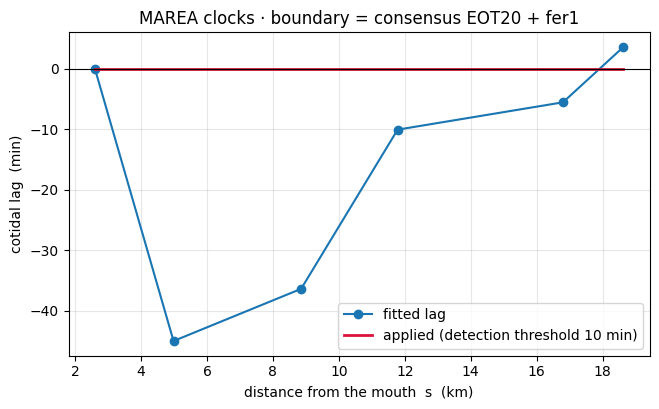

In [10]:
EXTRACT = f"{OUT_DIR}/marea_extract.npz"
if os.path.exists(EXTRACT):
    z_ = np.load(EXTRACT, allow_pickle=True)
    ex = {k: z_[k] for k in z_.files}
    ex["shape"] = tuple(int(v) for v in ex["shape"])
    ex["bbox"] = ex["bbox"].item()
    ex["crs_wkt"] = str(ex["crs_wkt"])
    print(f"loaded {EXTRACT}")
else:
    ex = marea.extract(cube.cache_path)
    seeds = pit.geometry.mouth_seeds(ex["sea"])
    s_m = pit.geometry.along_distance(ex["sea"] | ex["inter"], seeds, RESOLUTION_M)
    ex["s_km"] = (s_m.ravel()[ex["keep"]] / 1000.0).astype(np.float32)
    np.savez_compressed(EXTRACT, Y=ex["Y"], C=ex["C"], keep=ex["keep"],
                        dates=ex["dates"], shape=np.array(ex["shape"]),
                        sea=ex["sea"], inter=ex["inter"], s_km=ex["s_km"],
                        bbox=np.array(ex["bbox"], dtype=object),
                        crs_wkt=np.array(ex["crs_wkt"]))
    print(f"extracted and saved {EXTRACT}")
keep = ex["keep"]
assert ex["shape"] == (H, W), "extraction grid differs from the cube grid"
# distance from the mouth, measured from the sea on MOUTH_SIDE only, and
# written back so the background job shares it
seeds = pit.geometry.mouth_seeds(ex["sea"], side=MOUTH_SIDE)
s_m = pit.geometry.along_distance(ex["sea"] | ex["inter"], seeds, RESOLUTION_M)
ex["s_km"] = (s_m.ravel()[keep] / 1000.0).astype(np.float32)
s_km = ex["s_km"].astype(float)
np.savez_compressed(EXTRACT, Y=ex["Y"], C=ex["C"], keep=keep, dates=ex["dates"],
                    shape=np.array(ex["shape"]), sea=ex["sea"], inter=ex["inter"],
                    s_km=ex["s_km"], bbox=np.array(ex["bbox"], dtype=object),
                    crs_wkt=np.array(ex["crs_wkt"]))
print(f"{len(keep):,} intertidal px in the record "
      f"(pipeline mask above: {int(intertidal.sum()):,}); "
      f"s from the {MOUTH_SIDE} mouth up to {np.nanmax(s_km):.1f} km "
      f"({np.isnan(s_km).mean():.0%} hydraulically isolated px, no s)")

t0 = time.time()
marea_res = marea.reconstruct(cube.cache_path, out_dir=f"{OUT_DIR}/marea_{BOUNDARY_TAG}",
                              name=aoi.name, pixel_m=RESOLUTION_M,
                              boundary=boundary, extraction=ex,
                              mouth_side=MOUTH_SIDE)
assert marea_res["estado"] == "ok"
print(f"\nscenes with an exact overpass time: {marea_res['n_escenas']}")
print(f"pixels inverted: {marea_res['n_px_cota']:,} / {marea_res['n_px']:,}")
print(f"interior tide adopted: {marea_res['con_operador']}  "
      f"(physics veto: {marea_res['veto_fisico']})  [{time.time() - t0:.0f} s]")
mp = np.load(f"{OUT_DIR}/marea_{BOUNDARY_TAG}/marea.npz")
band_of, centres = mp["band"].astype(int), np.asarray(marea_res["centros_km"])
tau_fit, tau_used = np.asarray(marea_res["tau_min"]), np.asarray(marea_res["tau_usado_min"])

plt.figure(figsize=(7.5, 4.2))
plt.plot(centres, tau_fit, "o-", color="#1a76b3", label="fitted lag")
plt.step(centres, tau_used, where="mid", color="crimson", lw=2,
         label=f"applied (detection threshold {marea.TAU_DETECT_MIN:.0f} min)")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("distance from the mouth  s  (km)"); plt.ylabel("cotidal lag  (min)")
plt.title(f"MAREA clocks · boundary = {boundary.name}"); plt.legend(); plt.grid(alpha=0.3);
log.record("MAREA clocks", kind="fit", params={"n_bands": len(centres)},
           inputs=["wet/dry record", "boundary"],
           outputs=[f"tau per band: {np.round(tau_used, 0).tolist()} min"])

## 8 · Bathymetry without vs with the MAREA adjustment

**Same pixels, same scenes, same inversion.** The plain product reads the
boundary at the overpass time; the MAREA product reads it τ minutes earlier
in each band where τ was detected. The elevation grid (`lo`, `hi`) is shared,
so the two maps differ only through the clock.

Modelling tides with EOT20

record: 461 scenes × 103,759 px; level grid [-2.04, +1.29] m

plain inversion: 54,458 px  [26 s]

MAREA inversion: 52,916 px  [45 s]

Modelling tides with EOT20

...

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

fitted-clock (no threshold) inversion: 54,436 px  [114 s]

agreement with the shipped product: median |Δ| = 0.000 m, p95 0.000 m, 0.0% of px differ by > 5 cm

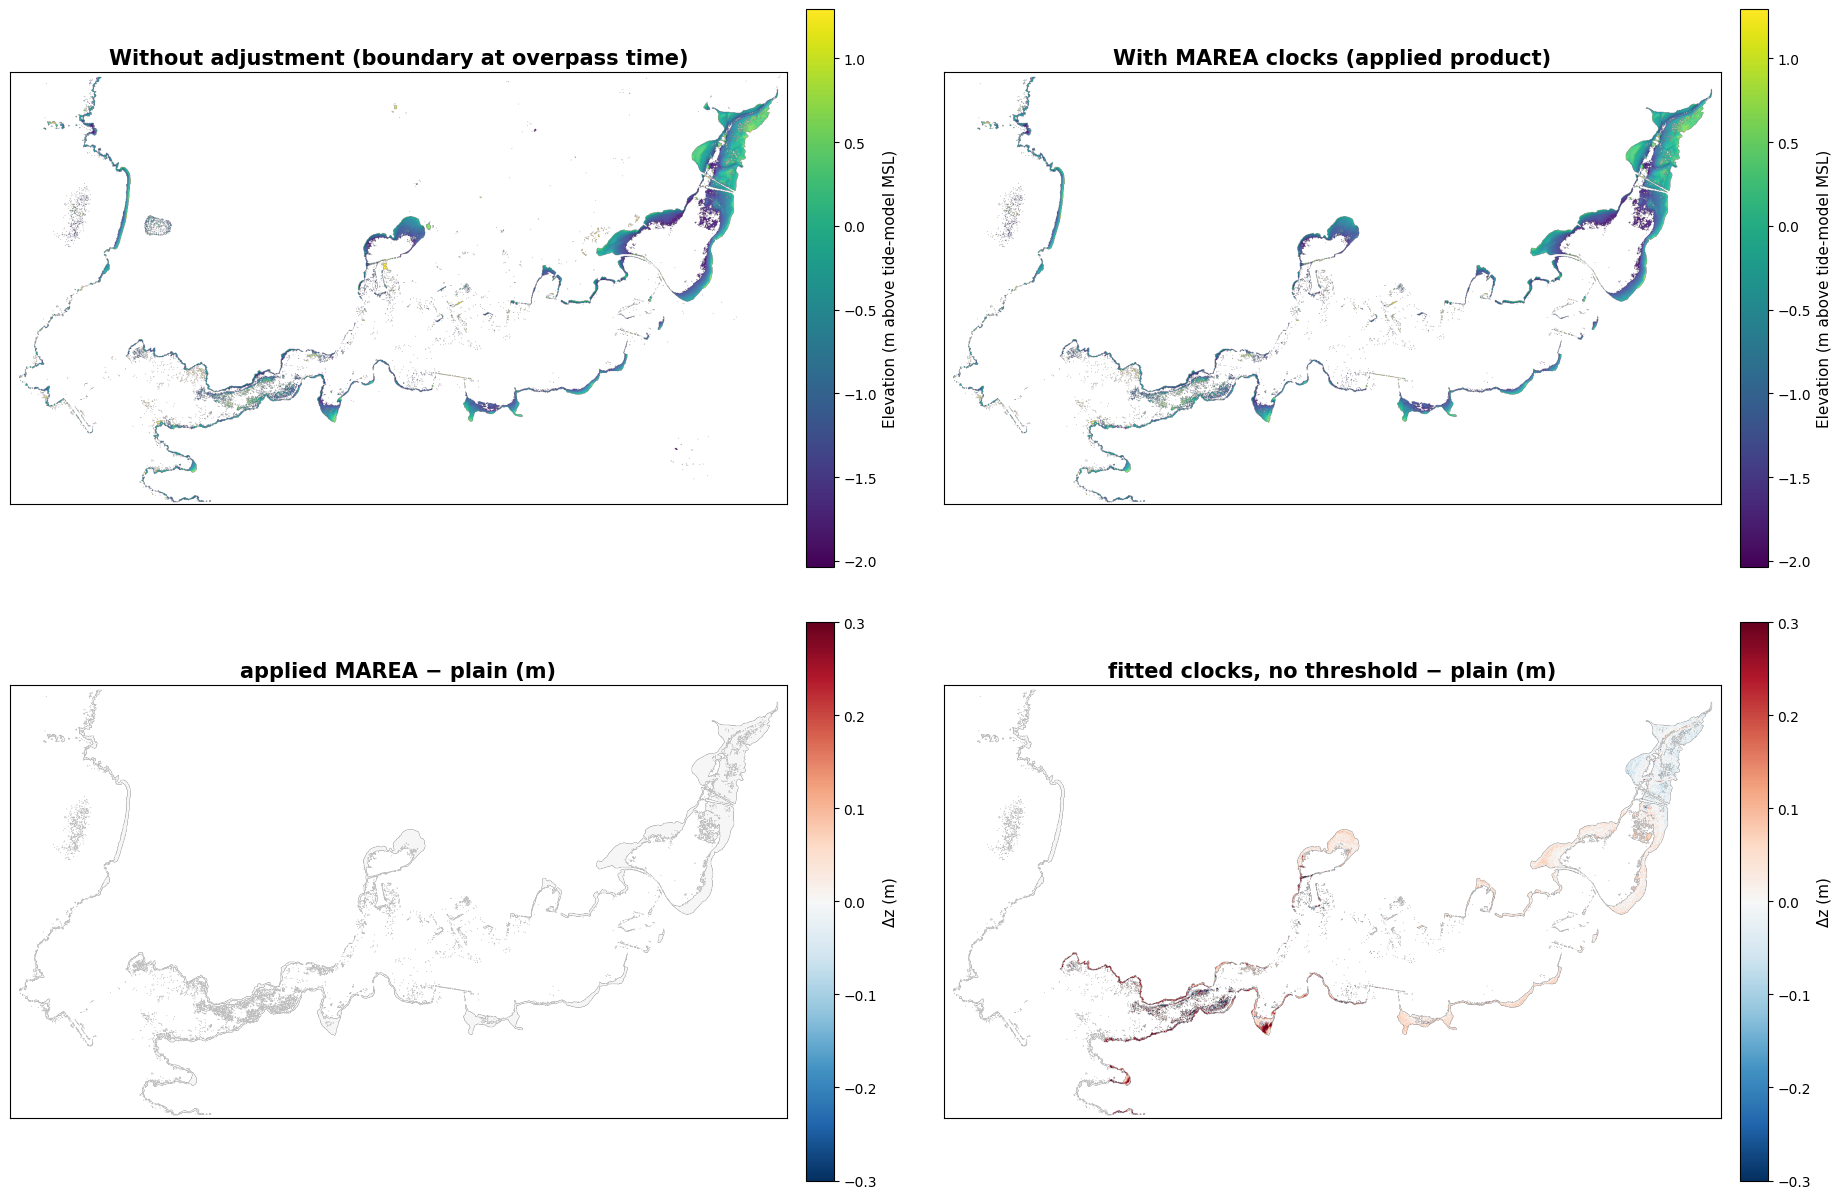

In [11]:
times_all = overpass                    # the catalogue lookup of section 6, reused
have = np.array([d in times_all for d in ex["dates"]])
t_real = pd.DatetimeIndex(pd.to_datetime([times_all[d] for d in ex["dates"][have]])).tz_localize(None)
Y = np.nan_to_num(ex["Y"][have], nan=0.0).astype(np.float32)
C = ex["C"][have].astype(np.float32)
h0 = np.asarray(boundary.levels(t_real), float)
okh = np.isfinite(h0)
Y, C, t_real, h0 = Y[okh], C[okh], t_real[okh], h0[okh]
lo, hi = float(h0.min()), float(h0.max())
print(f"record: {len(t_real)} scenes × {Y.shape[1]:,} px; level grid [{lo:+.2f}, {hi:+.2f}] m")

def to_raster(vals):
    r = np.full(H * W, np.nan, np.float32); r[keep] = vals
    return r.reshape(H, W)

t0 = time.time()
z_plain, sg_plain = marea.invert_series(Y, C, h0, lo, hi)
print(f"plain inversion: {int(np.isfinite(z_plain).sum()):,} px  [{time.time() - t0:.0f} s]")

z_marea = np.full(len(keep), np.nan)
for k in range(len(centres)):
    cols = np.flatnonzero(band_of == k)
    if not len(cols):
        continue
    h_k = (np.asarray(boundary.levels(t_real - pd.Timedelta(minutes=float(tau_used[k]))), float)
           if tau_used[k] else h0)
    z_marea[cols], _ = marea.invert_series(Y[:, cols], C[:, cols], h_k, lo, hi)
print(f"MAREA inversion: {int(np.isfinite(z_marea).sum()):,} px  [{time.time() - t0:.0f} s]")
# and the fitted clocks WITHOUT the detection threshold — not a product,
# a sensitivity row: what the map would look like if every band's fitted
# lag were believed
z_marea_fit = np.full(len(keep), np.nan)
for k in range(len(centres)):
    cols = np.flatnonzero(band_of == k)
    if not len(cols):
        continue
    h_k = np.asarray(boundary.levels(t_real - pd.Timedelta(minutes=float(tau_fit[k]))), float)
    z_marea_fit[cols], _ = marea.invert_series(Y[:, cols], C[:, cols], h_k, lo, hi)
print(f"fitted-clock (no threshold) inversion: {int(np.isfinite(z_marea_fit).sum()):,} px  [{time.time() - t0:.0f} s]")
# the shipped MAREA product used the identical call → it must agree
z_ship = mp["z"].astype(float)
m = np.isfinite(z_ship) & np.isfinite(z_marea)
dd = np.abs(z_ship[m] - z_marea[m])
print(f"agreement with the shipped product: median |Δ| = {np.median(dd):.3f} m, "
      f"p95 {np.percentile(dd, 95):.3f} m, {np.mean(dd > 0.05):.1%} of px differ by > 5 cm")

dem_plain, dem_marea, dem_fit = to_raster(z_plain), to_raster(z_marea), to_raster(z_marea_fit)
fig, axes = plt.subplots(2, 2, figsize=(19, 13))
viz.plot_dem(dem_plain, transform, crs, aoi, title="Without adjustment (boundary at overpass time)", ax=axes[0, 0])
viz.plot_dem(dem_marea, transform, crs, aoi, title="With MAREA clocks (applied product)", ax=axes[0, 1])
viz.plot_map(dem_marea - dem_plain, transform, crs, aoi, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
             robust=False, hillshade=False, title="applied MAREA − plain (m)", cbar_label="Δz (m)", ax=axes[1, 0])
viz.plot_map(dem_fit - dem_plain, transform, crs, aoi, cmap="RdBu_r", vmin=-0.3, vmax=0.3,
             robust=False, hillshade=False, title="fitted clocks, no threshold − plain (m)", cbar_label="Δz (m)", ax=axes[1, 1])
fig.tight_layout();

,band,s_km,tau_fitted_min,tau_applied_min,n_px,median_dz_m,p10_dz_m,p90_dz_m
0,0,2.60,0.0,0.0,6273,0.000,0.000,0.000
1,1,4.99,-45.0,0.0,4943,0.204,-0.204,0.544
2,2,8.86,-36.4,0.0,5218,0.068,-0.204,0.340
3,3,11.78,-10.1,0.0,8822,0.000,0.000,0.068
4,4,16.80,-5.5,0.0,12610,0.000,0.000,0.068
5,5,18.63,3.6,0.0,13833,0.000,-0.068,0.000


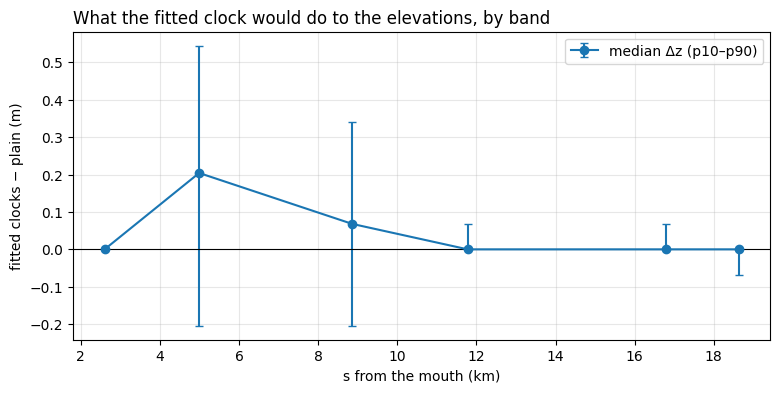

In [12]:
# where the clock acts: the difference by band of distance from the mouth
# (the fitted clocks, so the table says something even when the applied
# product keeps the boundary's clock everywhere)
d = z_marea_fit - z_plain
rows_ = []
for k in range(len(centres)):
    sel = (band_of == k) & np.isfinite(d)
    rows_.append({"band": k, "s_km": round(float(centres[k]), 2),
                  "tau_fitted_min": round(float(tau_fit[k]), 1),
                  "tau_applied_min": float(tau_used[k]), "n_px": int(sel.sum()),
                  "median_dz_m": float(np.median(d[sel])) if sel.any() else np.nan,
                  "p10_dz_m": float(np.percentile(d[sel], 10)) if sel.any() else np.nan,
                  "p90_dz_m": float(np.percentile(d[sel], 90)) if sel.any() else np.nan})
band_table = pd.DataFrame(rows_)
display(band_table.round(3))
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(band_table.s_km, band_table.median_dz_m,
            yerr=[band_table.median_dz_m - band_table.p10_dz_m, band_table.p90_dz_m - band_table.median_dz_m],
            fmt="o-", color="#1a76b3", capsize=3, label="median Δz (p10–p90)")
ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("s from the mouth (km)"); ax.set_ylabel("fitted clocks − plain (m)")
ax.set_title("What the fitted clock would do to the elevations, by band", loc="left"); ax.grid(alpha=0.3); ax.legend();

## 9 · MAREA vs Granadeiro

Granadeiro's product is the faithful reimplementation in
`experiments/sota_granadeiro.py` (inter-calibration on sea/land pixels,
Eq. 1 cosine heights between the boundary's extremes, per-pixel logistic on
standardised NIR, rising/ebbing lag sample, thin-plate-spline lag map,
Eq. 5 exposure), run under **this notebook's boundary** by
`experiments/e0_escalda_prep.py` (hours, so it is a background job — the
declared substitutions are in the script's header).

Three products are compared:

* **MAREA** — our clock, our estimator (section 8);
* **Granadeiro** — their clock, their estimator;
* **crossed** — their lag map, our inversion. If the crossed row sits with
  MAREA, the clocks agree and the estimator makes the difference; if it sits
  with Granadeiro, the clock does.

loaded products_ferrol/granadeiro_products_2023-2025_eot20_g1.npz: 52,587 px converged; lag map median -3 min, range [-103, +84]; 925 lag samples

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

...

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

Modelling tides with EOT20

crossed inversion: 55,710 px  [358 s]

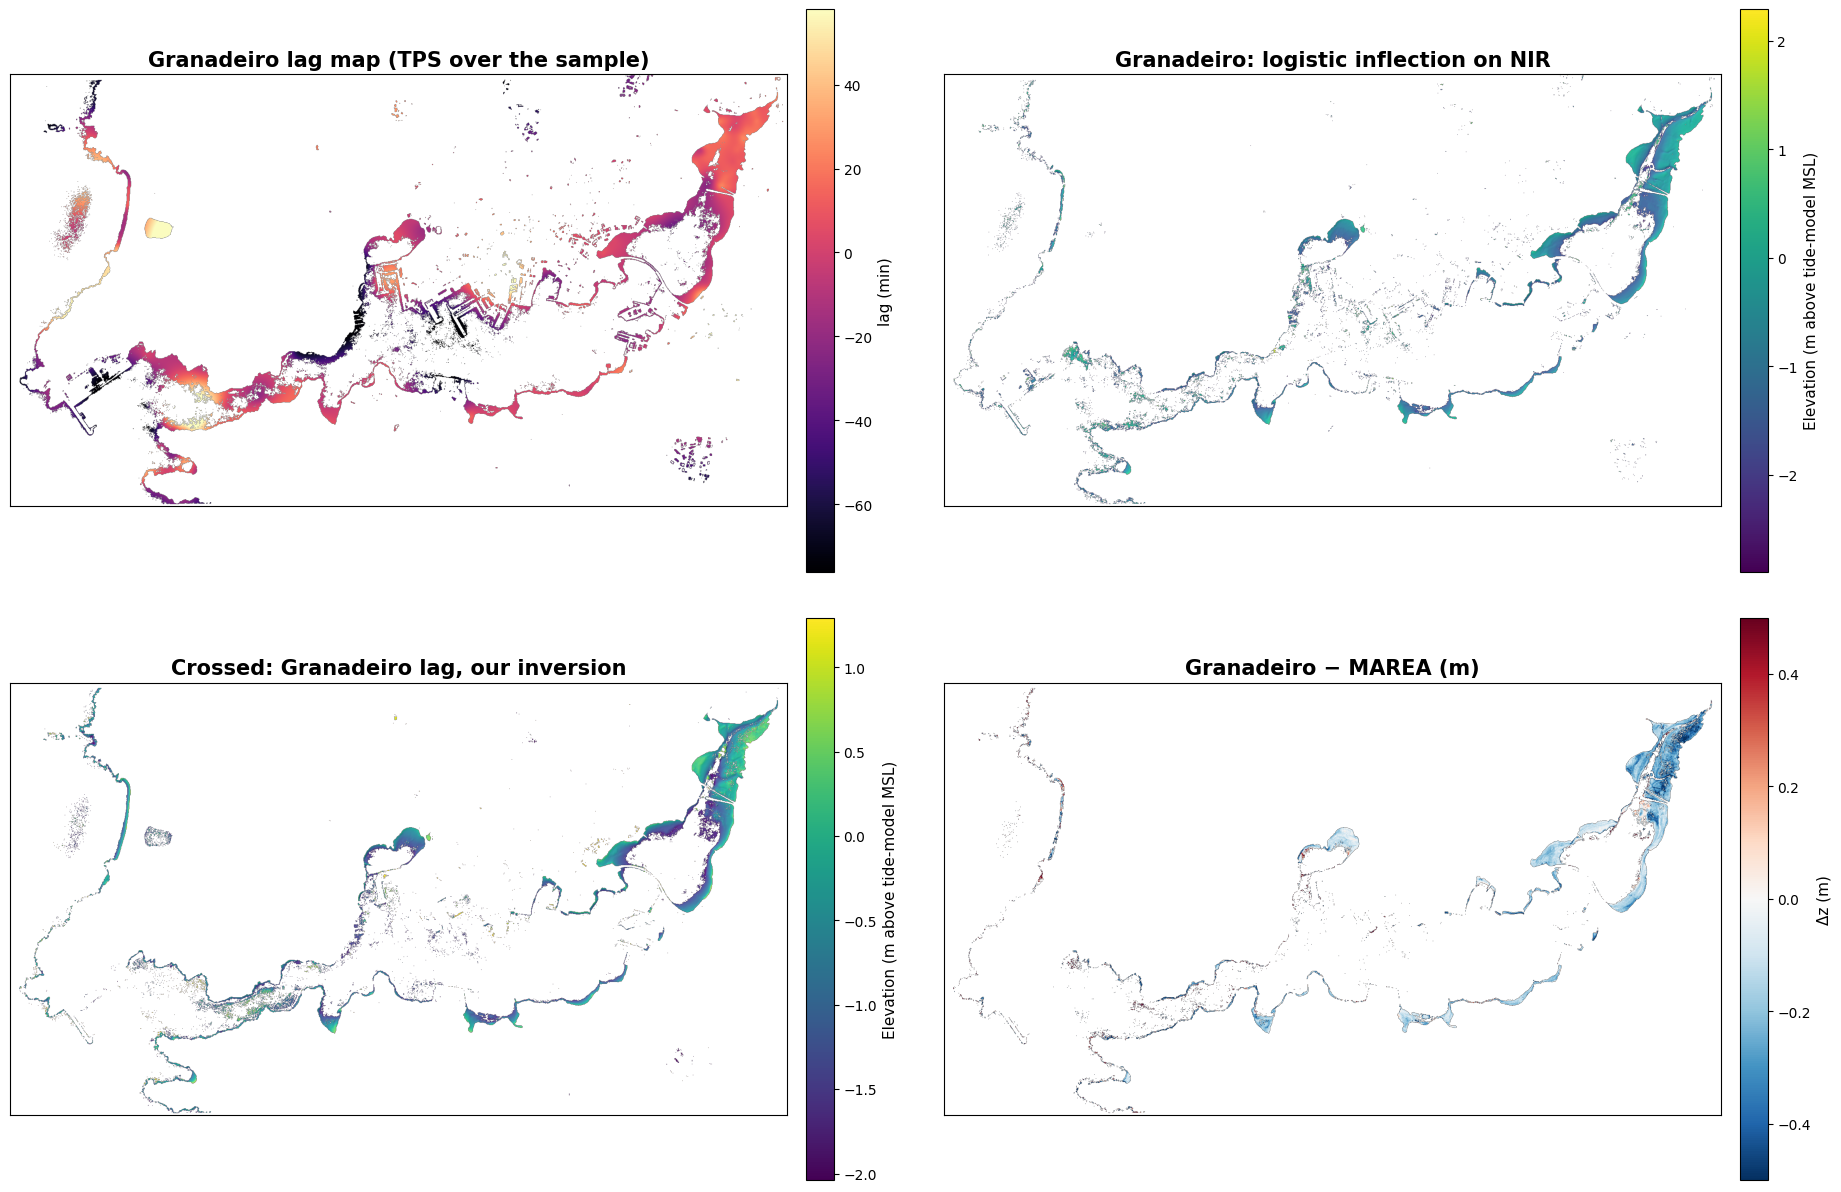

In [13]:
GRAN = f"{OUT_DIR}/granadeiro_products_2023-2025_{BOUNDARY_TAG}.npz"
gran = None
if os.path.exists(GRAN):
    gran = np.load(GRAN, allow_pickle=True)
    assert np.array_equal(gran["keep"], keep), "Granadeiro product is on other pixels"
    z_gran, lag_all = gran["final"].astype(float), gran["lag_all"].astype(float)
    print(f"loaded {GRAN}: {int(np.isfinite(z_gran).sum()):,} px converged; "
          f"lag map median {np.median(lag_all):+.0f} min, range "
          f"[{lag_all.min():+.0f}, {lag_all.max():+.0f}]; "
          f"{int(np.isfinite(gran['lag_sample']).sum())} lag samples")
    # crossed: their per-pixel lag, our inversion (lags quantised to 5 min)
    t0 = time.time()
    z_cross = np.full(len(keep), np.nan)
    lag_q = np.round(lag_all / 5.0) * 5.0
    for lq in np.unique(lag_q):
        cols = np.flatnonzero(lag_q == lq)
        h_q = np.asarray(boundary.levels(t_real - pd.Timedelta(minutes=float(lq))), float)
        z_cross[cols], _ = marea.invert_series(Y[:, cols], C[:, cols], h_q, lo, hi)
    print(f"crossed inversion: {int(np.isfinite(z_cross).sum()):,} px  [{time.time() - t0:.0f} s]")
    dem_gran, dem_cross, lag_map = to_raster(z_gran), to_raster(z_cross), to_raster(lag_all)
    fig, axes = plt.subplots(2, 2, figsize=(19, 13))
    viz.plot_map(lag_map, transform, crs, aoi, cmap="magma", robust=True, hillshade=False,
                 title="Granadeiro lag map (TPS over the sample)", cbar_label="lag (min)", ax=axes[0, 0])
    viz.plot_dem(dem_gran, transform, crs, aoi, title="Granadeiro: logistic inflection on NIR", ax=axes[0, 1])
    viz.plot_dem(dem_cross, transform, crs, aoi, title="Crossed: Granadeiro lag, our inversion", ax=axes[1, 0])
    viz.plot_map(dem_gran - dem_marea, transform, crs, aoi, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                 robust=False, hillshade=False, title="Granadeiro − MAREA (m)", cbar_label="Δz (m)", ax=axes[1, 1])
    fig.tight_layout()
else:
    print(f"{GRAN} not found — run:  python -m experiments.e0_escalda_prep "
          f"{TIDE_MODEL or 'none'} {N_GAUGES or 'none'}   (hours; background)")

common subset: 39,789 px

,product,n_px,median offset vs MAREA (m),"spread vs MAREA, IQR (m)",RMS vs MAREA after centring (m),corr with MAREA
0,plain (no clock),54458,0.000,0.000,0.000,1.000
1,MAREA,52916,0.000,0.000,0.000,1.000
2,"crossed (their lag, our inversion)",55710,0.000,0.068,0.152,0.972
3,Granadeiro,52587,-0.174,0.187,0.489,0.710


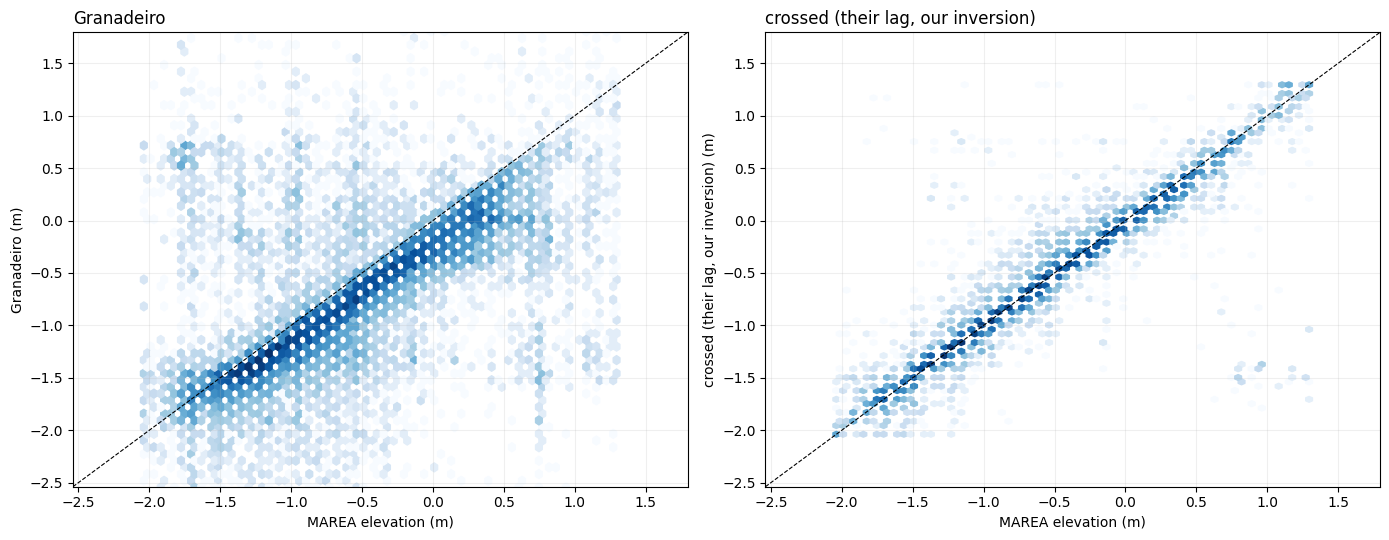

In [14]:
if gran is not None:
    prods = {"plain (no clock)": z_plain, "MAREA": z_marea,
             "crossed (their lag, our inversion)": z_cross, "Granadeiro": z_gran}
    common = np.ones(len(keep), bool)
    for v in prods.values():
        common &= np.isfinite(v)
    ref = z_marea[common]
    rows_ = []
    for k, v in prods.items():
        dv = v[common] - ref
        rows_.append({"product": k, "n_px": int(np.isfinite(v).sum()),
                      "median offset vs MAREA (m)": float(np.median(dv)),
                      "spread vs MAREA, IQR (m)": float(np.subtract(*np.percentile(dv, [75, 25]))),
                      "RMS vs MAREA after centring (m)": float(np.sqrt(np.mean((dv - np.median(dv)) ** 2))),
                      "corr with MAREA": float(np.corrcoef(v[common], ref)[0, 1])})
    print(f"common subset: {int(common.sum()):,} px")
    display(pd.DataFrame(rows_).round(3))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, (k, v) in zip(axes, [("Granadeiro", z_gran), ("crossed (their lag, our inversion)", z_cross)]):
        ax.hexbin(ref, v[common], gridsize=70, bins="log", cmap="Blues")
        lim = (lo - 0.5, hi + 0.5); ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel("MAREA elevation (m)"); ax.set_ylabel(f"{k} (m)"); ax.set_title(k, loc="left"); ax.grid(alpha=0.2)
    fig.tight_layout()

## 10 · Error metrics from the gauges

The judge gauge measured the water level inside the estuary at every minute
of the period. Each method claims to know the lag between the boundary and
that point, so each one predicts a level series there: the boundary read
τ minutes earlier, with τ from the method at the gauge's position on the
axis (MAREA: the band profile interpolated at the gauge's `s`; Granadeiro:
the lag map at the intertidal pixels nearest the gauge; plain: τ = 0). The
**median-centred RMSE** against the record is datum-free — a gauge datum is
not the model's MSL — and, because nothing was fitted on the judge, the whole
period is the test window. A best-lag sweep against the gauge gives the
ceiling any clock can reach; the rest of the error is surge and harmonics
the boundary itself gets wrong at that point.

The same metric is also reported for **every boundary option as-is** at every
gauge not inside it — what each boundary is worth before any method touches
it.

judge fer2 (Ferrol2): s = 10.14 km on the axis (nearest 200 intertidal px within 0.2 km); 151,063 10-min samples

,judge,row,tau_min,rmse_m,n
0,fer2,boundary as-is (no clock),0.0,0.1123,151063
1,fer2,MAREA applied clock (τ=+0.0 min),0.0,0.1123,151063
2,fer2,"MAREA fitted clock, no threshold (τ=-24.8 min)",-24.8,0.2427,151063
3,fer2,Granadeiro lag map (τ=-26.4 min),-26.4,0.2534,151063
4,fer2,ceiling: best lag against the gauge (τ=+5.0 min),5.0,0.1083,151063


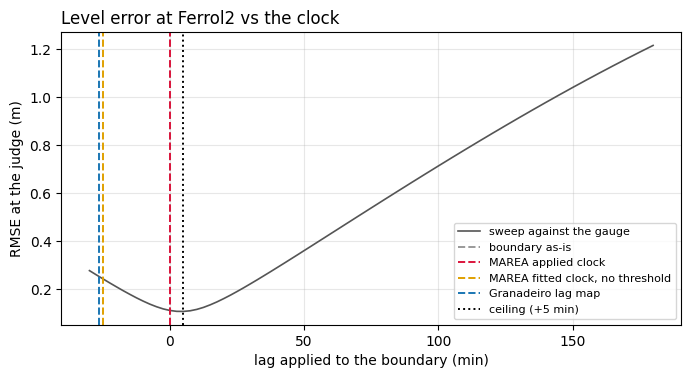

In [15]:
import pyproj
fwd = pyproj.Transformer.from_crs("EPSG:4326", crs, always_xy=True)
rows_k, cols_k = keep // W, keep % W
grid10 = pd.date_range(TIME_EXTENT[0], pd.Timestamp(TIME_EXTENT[1]) + pd.Timedelta(days=1), freq="10min")
tg = grid10.values.astype("int64") / 1e9
t5 = grid5.values.astype("int64") / 1e9

def gauge_truth(code_):
    df = load_cached_ioc(code_)
    df = despike(df[(df["time"] >= TIME_EXTENT[0]) & (df["time"] <= TIME_EXTENT[1])])
    s = pd.Series(df["level_m"].to_numpy(float), index=pd.DatetimeIndex(df["time"]))
    s = s[~s.index.duplicated()].sort_index()
    v = s.reindex(grid10, method="nearest", tolerance=pd.Timedelta("10min")).to_numpy(float)
    return v - np.nanmedian(v)

def shifted(levels5, tau_min):
    return np.interp(tg - 60.0 * tau_min, t5, levels5, left=np.nan, right=np.nan)

def rmse_centred(pred, truth):
    m = np.isfinite(pred) & np.isfinite(truth)
    d = pred[m] - truth[m]
    return float(np.sqrt(np.mean((d - np.median(d)) ** 2))), int(m.sum())

def gauge_axis_position(code_):
    st = stations[code_]
    x, y = fwd.transform(float(st["Lon"]), float(st["Lat"]))
    col, row = ~transform * (x, y)
    dpx = np.hypot(rows_k - row, cols_k - col)
    nearest = np.argsort(dpx)[:200]                 # the 200 nearest intertidal px
    return float(np.nanmedian(s_km[nearest])), nearest, float(dpx[nearest].max() * RESOLUTION_M / 1000)

judges = [c for c in JUDGE_GAUGES if c in stations]
results = []
for jc in judges:
    truth = gauge_truth(jc)
    s_j, near_px, reach_km = gauge_axis_position(jc)
    tau_marea = float(np.interp(s_j, centres, tau_used))
    tau_marea_fit = float(np.interp(s_j, centres, tau_fit))
    print(f"judge {jc} ({stations[jc]['Location']}): s = {s_j:.2f} km on the axis "
          f"(nearest 200 intertidal px within {reach_km:.1f} km); "
          f"{int(np.isfinite(truth).sum()):,} 10-min samples")
    preds = {"boundary as-is (no clock)": 0.0,
             f"MAREA applied clock (τ={tau_marea:+.1f} min)": tau_marea,
             f"MAREA fitted clock, no threshold (τ={tau_marea_fit:+.1f} min)": tau_marea_fit}
    if gran is not None:
        tau_gran = float(np.nanmedian(lag_all[near_px]))
        preds[f"Granadeiro lag map (τ={tau_gran:+.1f} min)"] = tau_gran
    for name, tv in preds.items():
        r, n = rmse_centred(shifted(lev5["boundary"], tv), truth)
        results.append({"judge": jc, "row": name, "tau_min": round(tv, 1), "rmse_m": r, "n": n})
    sweep = {tv: rmse_centred(shifted(lev5["boundary"], tv), truth)[0] for tv in np.arange(-30, 181, 2.5)}
    tb = min(sweep, key=sweep.get)
    results.append({"judge": jc, "row": f"ceiling: best lag against the gauge (τ={tb:+.1f} min)",
                    "tau_min": tb, "rmse_m": sweep[tb], "n": n})
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(list(sweep), list(sweep.values()), "-", color="#555", lw=1.2, label="sweep against the gauge")
    for (name, tv), col in zip(preds.items(), ["#999999", "crimson", "#e0a000", "#1a76b3"]):
        ax.axvline(tv, ls="--", lw=1.4, color=col, label=name.split(" (")[0])
    ax.axvline(tb, ls=":", lw=1.4, color="k", label=f"ceiling ({tb:+.0f} min)")
    ax.set_xlabel("lag applied to the boundary (min)"); ax.set_ylabel("RMSE at the judge (m)")
    ax.set_title(f"Level error at {stations[jc]['Location']} vs the clock", loc="left"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
judge_table = pd.DataFrame(results)
display(judge_table.round(4))

In [16]:
# every boundary option as-is, at every gauge that is not one of its members
member_sets = {}
if TIDE_MODEL:
    member_sets[f"model {TIDE_MODEL}"] = set()
if N_GAUGES:
    member_sets[f"{N_GAUGES} nearest gauges"] = set(member_codes)
if TIDE_MODEL and N_GAUGES:
    member_sets["consensus"] = set(member_codes)
all_codes = [g[0] for g in near if g[0] in stations and load_cached_ioc(g[0]) is not None]
rows_ = []
for opt, mem in member_sets.items():
    for gc in all_codes:
        if gc in mem:
            continue
        r, n = rmse_centred(shifted(lev5[opt], 0.0), gauge_truth(gc))
        rows_.append({"boundary option": opt, "gauge": gc, "location": stations[gc]["Location"],
                      "role": "judge" if gc in JUDGE_GAUGES else "not a member",
                      "rmse_as_is_m": r, "n": n})
display(pd.DataFrame(rows_).round(4))

,boundary option,gauge,location,role,rmse_as_is_m,n
0,model EOT20,fer2,Ferrol2,judge,0.1544,151063
1,model EOT20,fer1,Ferrol1,not a member,0.1289,149392
2,model EOT20,lang,Langosteira,not a member,0.1248,13656
3,1 nearest gauges,fer2,Ferrol2,judge,0.0960,143612
4,1 nearest gauges,lang,Langosteira,not a member,0.0366,13217
5,consensus,fer2,Ferrol2,judge,0.1123,151063
6,consensus,lang,Langosteira,not a member,0.0711,13656


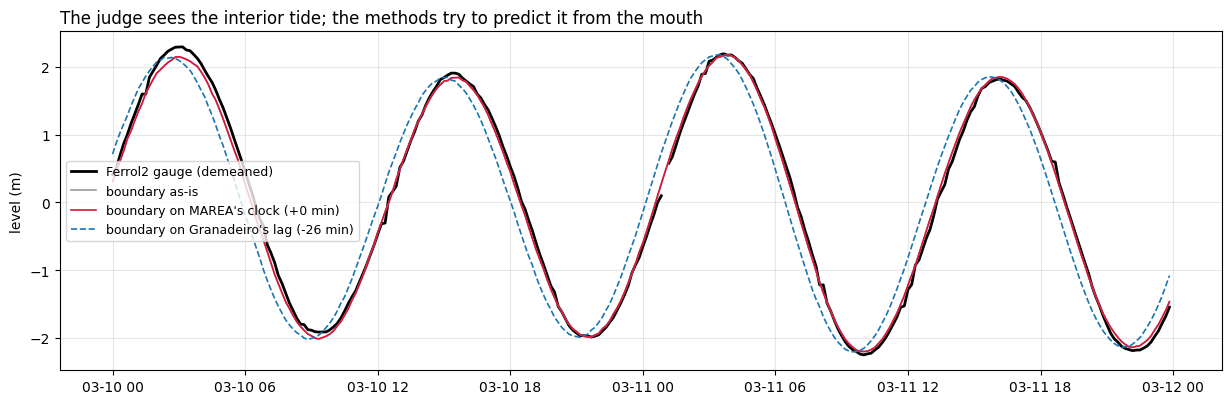

In [17]:
# one window at the judge: what each clock does to the predicted level
jc = judges[0]
truth = gauge_truth(jc)
win = (grid10 >= d0) & (grid10 < d0 + pd.Timedelta(days=2))
fig, ax = plt.subplots(figsize=(15, 4.4))
ax.plot(grid10[win], truth[win], "k", lw=2, label=f"{stations[jc]['Location']} gauge (demeaned)")
ax.plot(grid10[win], shifted(lev5["boundary"], 0.0)[win], color="#999", lw=1.2, label="boundary as-is")
ax.plot(grid10[win], shifted(lev5["boundary"], tau_marea)[win], color="crimson", lw=1.2,
        label=f"boundary on MAREA's clock ({tau_marea:+.0f} min)")
if gran is not None:
    ax.plot(grid10[win], shifted(lev5["boundary"], tau_gran)[win], color="#1a76b3", lw=1.2, ls="--",
            label=f"boundary on Granadeiro's lag ({tau_gran:+.0f} min)")
ax.set_ylabel("level (m)"); ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax.set_title("The judge sees the interior tide; the methods try to predict it from the mouth", loc="left");

## 11 · Summary and provenance

In [18]:
summary = []
for name, z in [("plain (no clock)", z_plain), ("MAREA (applied)", z_marea),
                ("MAREA fitted clocks, no threshold", z_marea_fit)] + (
        [("crossed (their lag, our inversion)", z_cross), ("Granadeiro", z_gran)] if gran is not None else []):
    summary.append({"product": name, "px mapped": int(np.isfinite(z).sum()),
                    "median z (m)": float(np.nanmedian(z)),
                    "median |Δz| vs plain (m)": float(np.nanmedian(np.abs(z - z_plain)))})
print(f"boundary: {boundary.name}   ·   judge: {', '.join(judges)}")
display(pd.DataFrame(summary).round(3))
print("\nlevel error at the judge (median-centred RMSE, whole period):")
display(judge_table[["judge", "row", "rmse_m"]].round(4))

os.makedirs(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}", exist_ok=True)
np.savez_compressed(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/products.npz",
                    keep=keep, shape=np.array([H, W]), s_km=s_km, band=band_of,
                    z_plain=z_plain, z_marea=z_marea, z_marea_fit=z_marea_fit,
                    **({"z_cross": z_cross, "z_gran": z_gran, "lag_all": lag_all} if gran is not None else {}))
judge_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/judge_metrics.csv", index=False)
band_table.to_csv(f"{OUT_DIR}/comparison_{BOUNDARY_TAG}/marea_effect_by_band.csv", index=False)
print(f"\n-> {OUT_DIR}/comparison_{BOUNDARY_TAG}/")
explain.draw_graph(log)

boundary: consensus EOT20 + fer1   ·   judge: fer2

,product,px mapped,median z (m),median |Δz| vs plain (m)
0,plain (no clock),54458,-0.678,0.000
1,MAREA (applied),52916,-0.746,0.000
2,"MAREA fitted clocks, no threshold",54436,-0.678,0.000
3,"crossed (their lag, our inversion)",55710,-0.746,0.068
4,Granadeiro,52587,-0.794,0.198



level error at the judge (median-centred RMSE, whole period):

,judge,row,rmse_m
0,fer2,boundary as-is (no clock),0.1123
1,fer2,MAREA applied clock (τ=+0.0 min),0.1123
2,fer2,"MAREA fitted clock, no threshold (τ=-24.8 min)",0.2427
3,fer2,Granadeiro lag map (τ=-26.4 min),0.2534
4,fer2,ceiling: best lag against the gauge (τ=+5.0 min),0.1083



-> products_ferrol/comparison_eot20_g1/

<pyintertidal diagram: process graph · Escalda 2023–2025 — display it in a notebook or call .save(path)>

## Notes

* **Grid.** 10 m: the cube was downloaded at that resolution to keep
  three years of the box tractable on disk. Every product here is on that
  grid.
* **Datum.** The boundary is demeaned gauge level, model MSL, or their mean;
  elevations are relative to it. Map differences are reported raw and
  median-centred; level errors are median-centred (datum-free).
* **Same extraction for both methods.** `marea.extract` defines the pixels
  and the clear-sky mask; Granadeiro's NIR was read at those pixels. The
  pipeline mask of section 4 (polygon-clipped, 0.05–0.95) is the product
  mask; the extraction (0.10–0.90, no clip) is the estimation record.
* **Granadeiro substitutions** (declared in `experiments/sota_granadeiro.py`):
  Sen2Cor instead of ACOLITE, scipy least-squares instead of `nplr`, scipy
  thin-plate RBF instead of `mgcv`, lag sample of 1000 pixels, and the
  scene rule: their "< 10 % cloud over the whole frame" is replaced by
  "at most 20 % of the intertidal pixels cloudy", clouds still masked per
  pixel — on the Scheldt the frame rule left 33 scenes (11 rising, and
  their logistic needs 12) because the frame is mostly sea and far land.
* **Distance axis.** `s` is the geodesic distance through water from the
  sea on the `MOUTH_SIDE` edge(s). Pixels no water path reaches
  have no `s` and fall in no band.
* **Reserved data.** Nothing here touches the Villaviciosa RTK blocks; the
  only truth is the held-out gauge.